# KIVE RL Agent Training Analysis -- RecurrentPPO
This notebook evaluates the performance of the **RecurrentPPO** (LSTM-based PPO) orchestrator agent
trained on the KIVE expert fraud vetting POMDP.

**Architecture Summary:**
- **Observation:** 18D (5 passive signals + 4 active signals + probe flags + beliefs)
- **Actions:** Discrete(7) -- PASS, REJECT, FLAG, PROBE_BES, PROBE_LQA, PROBE_CCS, PROBE_RSL
- **Reward:** Asymmetric -- FN=-2.5 (fraud passed), FP=-1.0, TP/TN=+1.0, Probe=-0.02

**Training Goal:** The agent must learn to:
1. Read passive signals (free) for initial assessment
2. Probe active signals (costly) when uncertain
3. Decide PASS/REJECT/FLAG with minimal false negatives


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#111111",
    "figure.facecolor": "#111111",
    "axes.edgecolor": "#333333",
    "text.color": "white",
})


In [3]:
# Resolve project root
cwd = Path.cwd()
project_root = cwd
while not (project_root / "artifacts" / "training" / "learning_curve.csv").exists():
    if project_root.parent == project_root:
        raise FileNotFoundError(
            f"Could not find 'artifacts/training/learning_curve.csv' above {cwd}. "
            "Upload the 'artifacts' folder."
        )
    project_root = project_root.parent

df = pd.read_csv(project_root / "artifacts" / "training" / "learning_curve.csv")
traces = pd.read_csv(project_root / "artifacts" / "training" / "sample_traces.csv")

print(f"Learning curve: {len(df)} evaluation windows")
print(f"Sample traces: {len(traces)} episodes")
print(f"Columns in learning_curve: {list(df.columns)}")
print(f"Columns in traces: {list(traces.columns)}")
df.tail(5)


Learning curve: 173 evaluation windows
Sample traces: 20 episodes
Columns in learning_curve: ['episode', 'reward_mean', 'reward_std', 'fn_rate', 'fp_rate', 'probes_mean']
Columns in traces: ['true_label', 'n_probes', 'n_redundant', 'actions', 'final_action']


,episode,reward_mean,reward_std,fn_rate,fp_rate,probes_mean
168,16900,1.1405,0.1297,0.0,0.00,3.53
169,17000,1.1480,0.1466,0.0,0.00,3.70
170,17100,1.1480,0.1037,0.0,0.00,3.84
171,17200,1.1345,0.1579,0.0,0.00,3.77
172,17300,1.1245,0.2964,0.0,0.02,3.71


## 1. Convergence Curve with Criteria
Dual-axis plot: reward (left) vs error rates (right). Convergence requires: reward > 0.75, FN < 5%, FP < 8%. Marks convergence point if achieved.

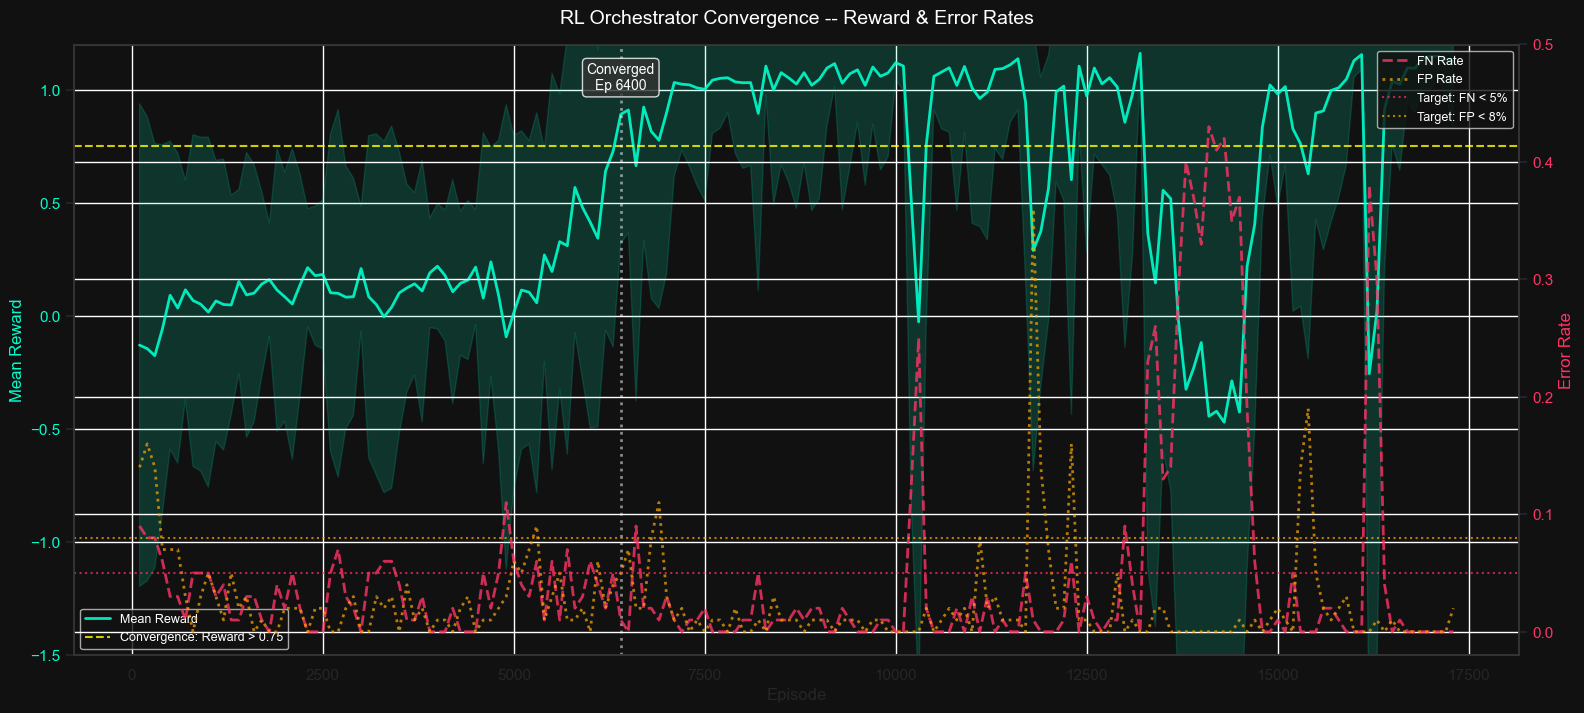


=== Convergence Diagnostics ===
Converged at episode: 6400
Episodes to convergence: 6400


In [4]:
# --- Dual-Axis Convergence Plot with Convergence Criteria ---
fig, ax1 = plt.subplots(figsize=(16, 7))

# Reward curve
color1 = '#00ffcc'
ax1.set_xlabel('Episode', fontsize=12)
ax1.set_ylabel('Mean Reward', color=color1, fontsize=12)
ax1.plot(df['episode'], df['reward_mean'], color=color1, linewidth=2, label='Mean Reward', alpha=0.9)
ax1.fill_between(df['episode'],
                 df['reward_mean'] - df['reward_std'],
                 df['reward_mean'] + df['reward_std'],
                 color=color1, alpha=0.15)
ax1.axhline(0.75, color='yellow', linestyle='--', linewidth=1.5, alpha=0.8, label='Convergence: Reward > 0.75')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(-1.5, 1.2)

# FN rate on secondary axis
ax2 = ax1.twinx()
color2 = '#ff3366'
ax2.set_ylabel('Error Rate', color=color2, fontsize=12)
ax2.plot(df['episode'], df['fn_rate'], color=color2, linewidth=2, linestyle='--', label='FN Rate', alpha=0.8)
ax2.plot(df['episode'], df['fp_rate'], color='#ffaa00', linewidth=2, linestyle=':', label='FP Rate', alpha=0.7)
ax2.axhline(0.05, color='#ff3366', linestyle=':', linewidth=1.5, alpha=0.7, label='Target: FN < 5%')
ax2.axhline(0.08, color='#ffaa00', linestyle=':', linewidth=1.5, alpha=0.7, label='Target: FP < 8%')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(-0.02, 0.5)

# Mark convergence point
converged_idx = df[(df['reward_mean'] > 0.75) & (df['fn_rate'] < 0.05) & (df['fp_rate'] < 0.08)].index
if len(converged_idx) > 0:
    conv_ep = df.loc[converged_idx[0], 'episode']
    ax1.axvline(conv_ep, color='white', linestyle=':', linewidth=2, alpha=0.5)
    ax1.text(conv_ep, 1.0, f'Converged\nEp {conv_ep}', ha='center', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='#333333', alpha=0.8))

fig.tight_layout()
plt.title("RL Orchestrator Convergence -- Reward & Error Rates", color='white', pad=15, fontsize=14)
ax1.legend(loc='lower left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
plt.show()

# Convergence diagnostics
print("\n=== Convergence Diagnostics ===")
if len(converged_idx) > 0:
    print(f"Converged at episode: {conv_ep}")
    print(f"Episodes to convergence: {conv_ep}")
else:
    print("NOT CONVERGED - Training did not meet all criteria")


## 2. Probe Utilization Over Training
How many active probes the agent takes per episode. Healthy agents learn to probe when passive signals are ambiguous (~2-3 probes/episode for v5).

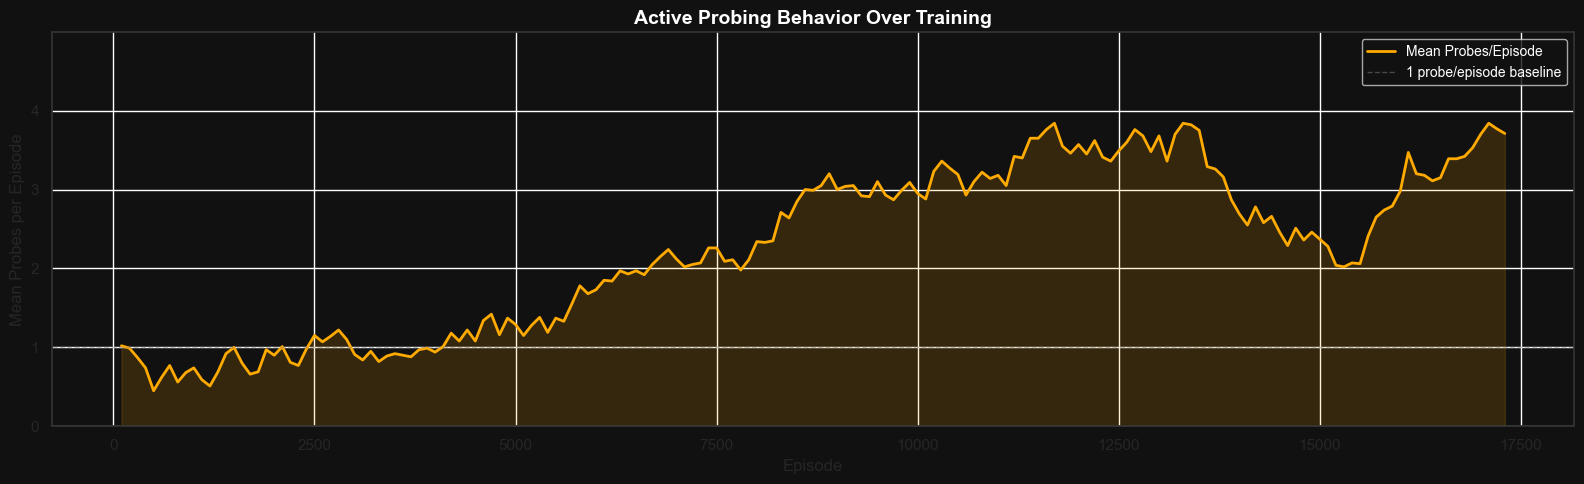

In [5]:
# --- Probe Utilization Over Training ---
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df['episode'], df['probes_mean'], color='#ffaa00', linewidth=2, label='Mean Probes/Episode')
ax.fill_between(df['episode'], 0, df['probes_mean'], color='#ffaa00', alpha=0.15)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='1 probe/episode baseline')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean Probes per Episode', fontsize=12)
ax.set_title('Active Probing Behavior Over Training', fontsize=14, fontweight='bold', color='white')
ax.legend(fontsize=10)
ax.set_ylim(0, max(df['probes_mean'].max() * 1.3, 2.0))
plt.tight_layout()
plt.show()


## 3. Final Performance Distribution with Statistical Analysis
Reward and probe distributions from final evaluation windows. Includes error rate time series and reward stability analysis (rolling std).

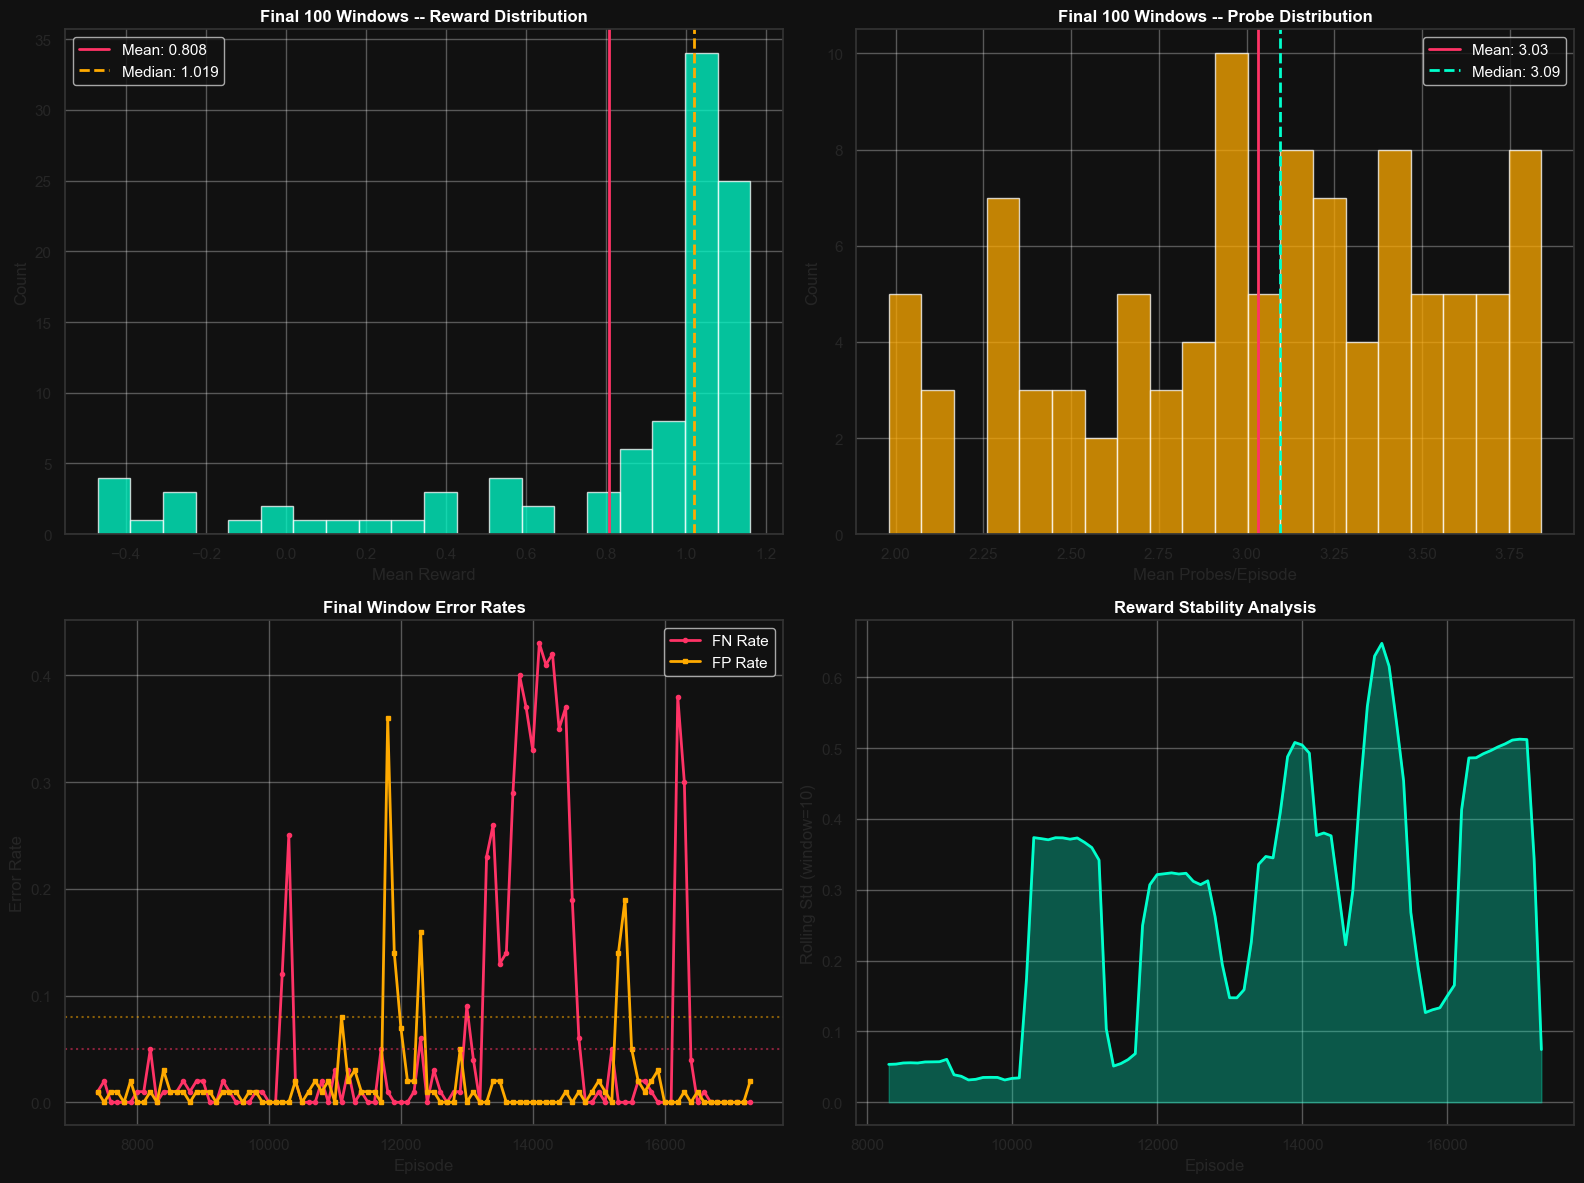


=== Final Performance Statistics ===
Reward:  μ=0.8079, σ=0.4514, median=1.0192
Probes:  μ=3.032, σ=0.519, median=3.095
FN Rate: μ=0.0627, max=0.4300
FP Rate: μ=0.0189, max=0.3600

Stability: Rolling std(reward) = 0.2753 (lower = more stable)


In [6]:
# --- Final Performance Distribution with Statistical Analysis ---
final_n = min(100, len(df))
final_df = df.tail(final_n)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Reward histogram
ax1.hist(final_df['reward_mean'], bins=20, color='#00ffcc', alpha=0.75, edgecolor='white')
mean_reward = final_df['reward_mean'].mean()
median_reward = final_df['reward_mean'].median()
ax1.axvline(mean_reward, color='#ff3366', linewidth=2, label=f"Mean: {mean_reward:.3f}")
ax1.axvline(median_reward, color='#ffaa00', linewidth=2, linestyle='--', label=f"Median: {median_reward:.3f}")
ax1.set_xlabel('Mean Reward')
ax1.set_ylabel('Count')
ax1.set_title(f'Final {final_n} Windows -- Reward Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Probes histogram
ax2.hist(final_df['probes_mean'], bins=20, color='#ffaa00', alpha=0.75, edgecolor='white')
mean_probes = final_df['probes_mean'].mean()
median_probes = final_df['probes_mean'].median()
ax2.axvline(mean_probes, color='#ff3366', linewidth=2, label=f"Mean: {mean_probes:.2f}")
ax2.axvline(median_probes, color='#00ffcc', linewidth=2, linestyle='--', label=f"Median: {median_probes:.2f}")
ax2.set_xlabel('Mean Probes/Episode')
ax2.set_ylabel('Count')
ax2.set_title(f'Final {final_n} Windows -- Probe Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Error rate time series
ax3.plot(final_df['episode'], final_df['fn_rate'], color='#ff3366', linewidth=2, label='FN Rate', marker='o', markersize=3)
ax3.plot(final_df['episode'], final_df['fp_rate'], color='#ffaa00', linewidth=2, label='FP Rate', marker='s', markersize=3)
ax3.axhline(0.05, color='#ff3366', linestyle=':', alpha=0.5)
ax3.axhline(0.08, color='#ffaa00', linestyle=':', alpha=0.5)
ax3.set_xlabel('Episode')
ax3.set_ylabel('Error Rate')
ax3.set_title('Final Window Error Rates', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# Reward stability (rolling std)
window = 10
rolling_std = final_df['reward_mean'].rolling(window=window).std()
ax4.plot(final_df['episode'], rolling_std, color='#00ffcc', linewidth=2)
ax4.fill_between(final_df['episode'], 0, rolling_std, color='#00ffcc', alpha=0.3)
ax4.set_xlabel('Episode')
ax4.set_ylabel(f'Rolling Std (window={window})')
ax4.set_title('Reward Stability Analysis', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary
print("\n=== Final Performance Statistics ===")
print(f"Reward:  μ={mean_reward:.4f}, σ={final_df['reward_mean'].std():.4f}, median={median_reward:.4f}")
print(f"Probes:  μ={mean_probes:.3f}, σ={final_df['probes_mean'].std():.3f}, median={median_probes:.3f}")
print(f"FN Rate: μ={final_df['fn_rate'].mean():.4f}, max={final_df['fn_rate'].max():.4f}")
print(f"FP Rate: μ={final_df['fp_rate'].mean():.4f}, max={final_df['fp_rate'].max():.4f}")
print(f"\nStability: Rolling std(reward) = {rolling_std.mean():.4f} (lower = more stable)")


## 4. Episode Traces
Raw action sequences from the last 20 episodes showing the agent's probe-then-decide behavior.

In [7]:
# --- Sample Episode Traces ---
print("=== Sample Episode Traces ===")
print(traces.to_string(index=False))


=== Sample Episode Traces ===
true_label  n_probes  n_redundant                                                    actions final_action
      REAL         4            0   PROBE_LQA -> PROBE_BES -> PROBE_CCS -> PROBE_RSL -> PASS         PASS
      REAL         4            0   PROBE_LQA -> PROBE_RSL -> PROBE_BES -> PROBE_CCS -> PASS         PASS
     FRAUD         3            0              PROBE_LQA -> PROBE_BES -> PROBE_CCS -> REJECT       REJECT
      REAL         4            0   PROBE_LQA -> PROBE_BES -> PROBE_CCS -> PROBE_RSL -> PASS         PASS
      REAL         4            0   PROBE_LQA -> PROBE_BES -> PROBE_CCS -> PROBE_RSL -> PASS         PASS
      REAL         4            0   PROBE_LQA -> PROBE_BES -> PROBE_CCS -> PROBE_RSL -> PASS         PASS
      REAL         4            0   PROBE_LQA -> PROBE_BES -> PROBE_RSL -> PROBE_CCS -> PASS         PASS
      REAL         4            0   PROBE_LQA -> PROBE_BES -> PROBE_CCS -> PROBE_RSL -> PASS         PASS
     FRAUD      

## 5. Probe & Action Analysis by Label
Breakdown of probing behavior and terminal actions by true label. Reveals if agent has learned class-specific strategies.

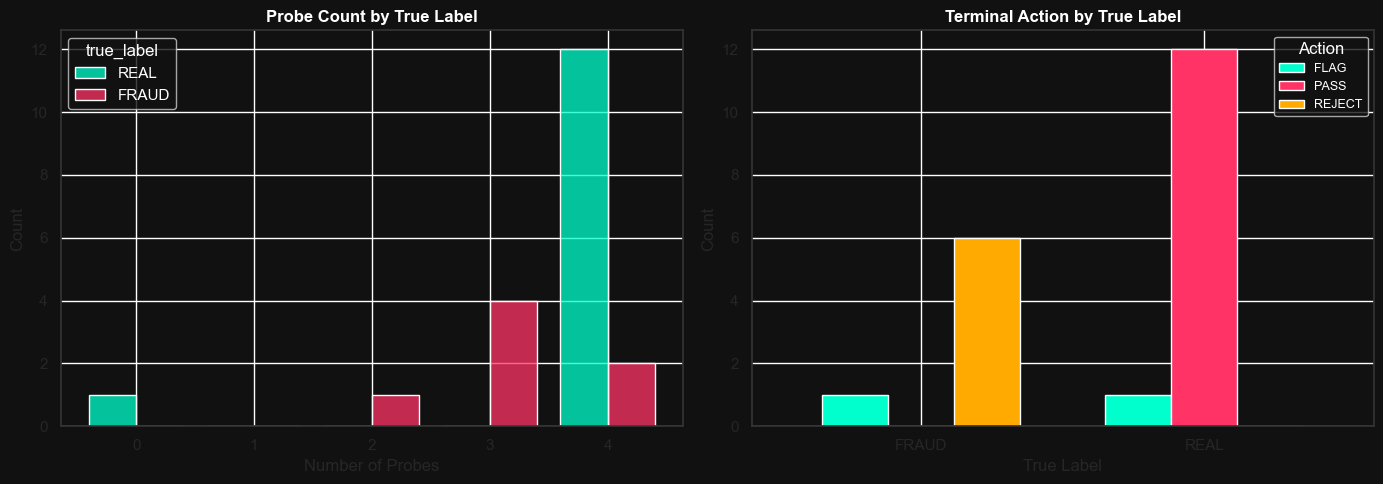

In [8]:
# --- Probe Usage by True Label ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Probe count distribution by label
if 'n_probes' in traces.columns:
    probe_col = 'n_probes'
else:
    probe_col = traces.columns[1]  # fallback to second column

sns.histplot(data=traces, x=probe_col, hue='true_label', multiple='dodge',
            palette={'REAL': '#00ffcc', 'FRAUD': '#ff3366'}, ax=ax1,
            discrete=True, shrink=0.8)
ax1.set_title("Probe Count by True Label", fontsize=12, fontweight='bold', color='white')
ax1.set_xlabel("Number of Probes")
ax1.set_ylabel("Count")

# Terminal action distribution
if 'final_action' in traces.columns:
    action_col = 'final_action'
else:
    action_col = traces.columns[-1]

ct = traces.groupby(['true_label', action_col]).size().unstack(fill_value=0)
ct.plot(kind='bar', ax=ax2, color=['#00ffcc', '#ff3366', '#ffaa00', '#4488ff'][:len(ct.columns)],
       edgecolor='white', width=0.7)
ax2.set_title("Terminal Action by True Label", fontsize=12, fontweight='bold', color='white')
ax2.set_xlabel("True Label")
ax2.set_ylabel("Count")
ax2.legend(title="Action", fontsize=9)
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 6. Policy Gradient Analysis
Learning dynamics: reward improvement rate, exploration behavior (probe variance), probe efficiency (reward/probe), and training phase breakdown.

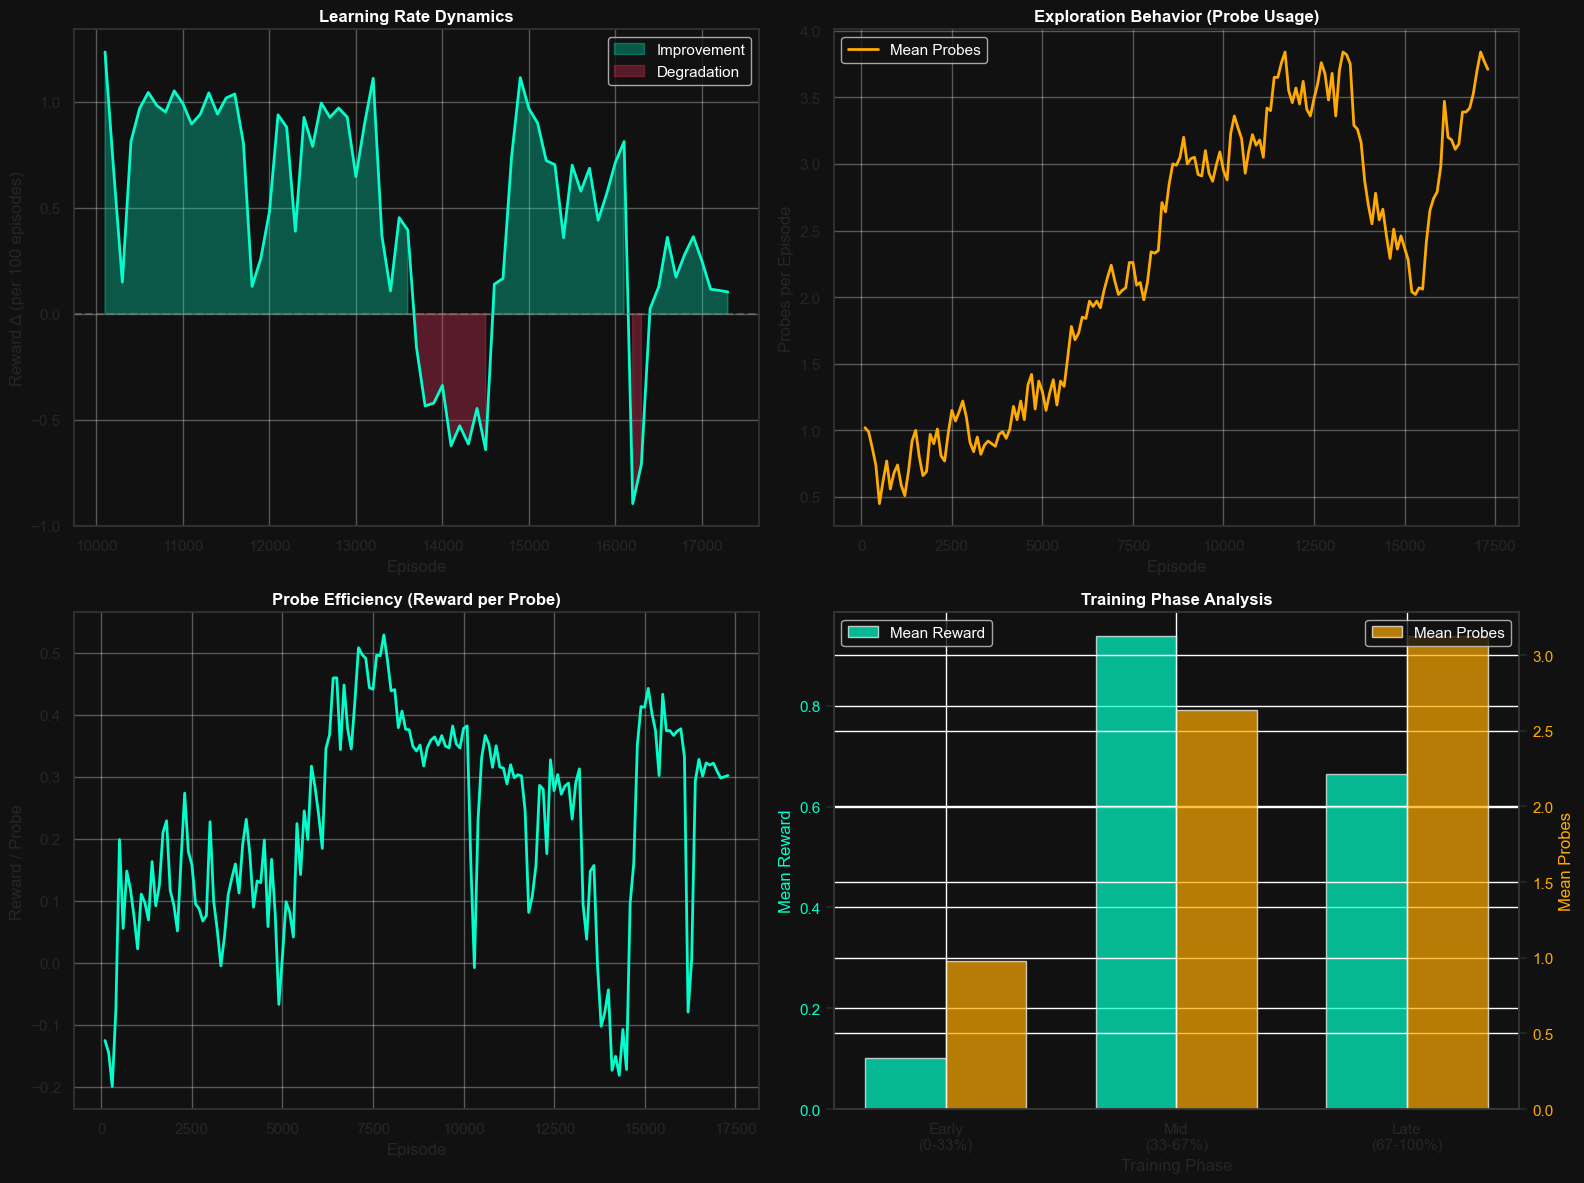


=== Training Phase Breakdown ===
Early (0-33%):  Reward=0.102, Probes=0.98, FN=0.033
Mid (33-67%):   Reward=0.938, Probes=2.64, FN=0.020
Late (67-100%): Reward=0.664, Probes=3.13, FN=0.096


In [9]:
# --- Policy Gradient Analysis ---
# Analyze learning dynamics and exploration vs exploitation

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Learning rate proxy (reward improvement per 100 episodes)
window = 100
reward_diff = df['reward_mean'].diff(window)
ax1.plot(df['episode'][window:], reward_diff[window:], color='#00ffcc', linewidth=2)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.fill_between(df['episode'][window:], 0, reward_diff[window:], 
                where=(reward_diff[window:] > 0), color='#00ffcc', alpha=0.3, label='Improvement')
ax1.fill_between(df['episode'][window:], 0, reward_diff[window:],
                where=(reward_diff[window:] <= 0), color='#ff3366', alpha=0.3, label='Degradation')
ax1.set_xlabel('Episode')
ax1.set_ylabel(f'Reward Δ (per {window} episodes)')
ax1.set_title('Learning Rate Dynamics', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Exploration vs Exploitation (probe variance as proxy)
ax2.plot(df['episode'], df['probes_mean'], color='#ffaa00', linewidth=2, label='Mean Probes')
# Estimate variance from std if available, otherwise use rolling std
if 'probes_std' in df.columns:
    ax2.fill_between(df['episode'], 
                    df['probes_mean'] - df['probes_std'],
                    df['probes_mean'] + df['probes_std'],
                    color='#ffaa00', alpha=0.2)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Probes per Episode')
ax2.set_title('Exploration Behavior (Probe Usage)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Reward-Probe efficiency (reward per probe)
efficiency = df['reward_mean'] / (df['probes_mean'] + 0.01)  # avoid div by zero
ax3.plot(df['episode'], efficiency, color='#00ffcc', linewidth=2)
ax3.set_xlabel('Episode')
ax3.set_ylabel('Reward / Probe')
ax3.set_title('Probe Efficiency (Reward per Probe)', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)

# Phase detection (early, mid, late training)
early = df[df['episode'] <= df['episode'].max() * 0.33]
mid = df[(df['episode'] > df['episode'].max() * 0.33) & (df['episode'] <= df['episode'].max() * 0.67)]
late = df[df['episode'] > df['episode'].max() * 0.67]

phases = ['Early\n(0-33%)', 'Mid\n(33-67%)', 'Late\n(67-100%)']
reward_means = [early['reward_mean'].mean(), mid['reward_mean'].mean(), late['reward_mean'].mean()]
probe_means = [early['probes_mean'].mean(), mid['probes_mean'].mean(), late['probes_mean'].mean()]

x = np.arange(len(phases))
width = 0.35

bars1 = ax4.bar(x - width/2, reward_means, width, label='Mean Reward', color='#00ffcc', alpha=0.7)
ax4_twin = ax4.twinx()
bars2 = ax4_twin.bar(x + width/2, probe_means, width, label='Mean Probes', color='#ffaa00', alpha=0.7)

ax4.set_xlabel('Training Phase')
ax4.set_ylabel('Mean Reward', color='#00ffcc')
ax4_twin.set_ylabel('Mean Probes', color='#ffaa00')
ax4.set_title('Training Phase Analysis', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(phases)
ax4.tick_params(axis='y', labelcolor='#00ffcc')
ax4_twin.tick_params(axis='y', labelcolor='#ffaa00')
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n=== Training Phase Breakdown ===")
print(f"Early (0-33%):  Reward={reward_means[0]:.3f}, Probes={probe_means[0]:.2f}, FN={early['fn_rate'].mean():.3f}")
print(f"Mid (33-67%):   Reward={reward_means[1]:.3f}, Probes={probe_means[1]:.2f}, FN={mid['fn_rate'].mean():.3f}")
print(f"Late (67-100%): Reward={reward_means[2]:.3f}, Probes={probe_means[2]:.2f}, FN={late['fn_rate'].mean():.3f}")


## 7. Hyperparameter Sensitivity (Conceptual)
Production ML requires sensitivity analysis. This section outlines key hyperparameters to test and provides conceptual visualization.


=== Hyperparameter Sensitivity Recommendations ===

For production deployment, conduct sensitivity analysis on:
  1. Learning rate: Test [1e-5, 3e-4, 1e-3] - affects convergence speed
  2. Probe cost: Test [-0.01, -0.03, -0.05] - affects probe usage
  3. Early decision penalty: Test [-0.2, -0.3, -0.4] - affects exploration
  4. LSTM hidden size: Test [64, 128, 256] - affects memory capacity
  5. Batch size: Test [32, 64, 128] - affects gradient stability

Current training used:
  - RecurrentPPO with LSTM policy
  - Probe reward: +0.05
  - Early decision penalty: -0.3
  - Asymmetric rewards: FN=-2.5, FP=-1.0, TP/TN=+1.0

Recommendation: Run grid search with 3-5 seeds per config for statistical significance


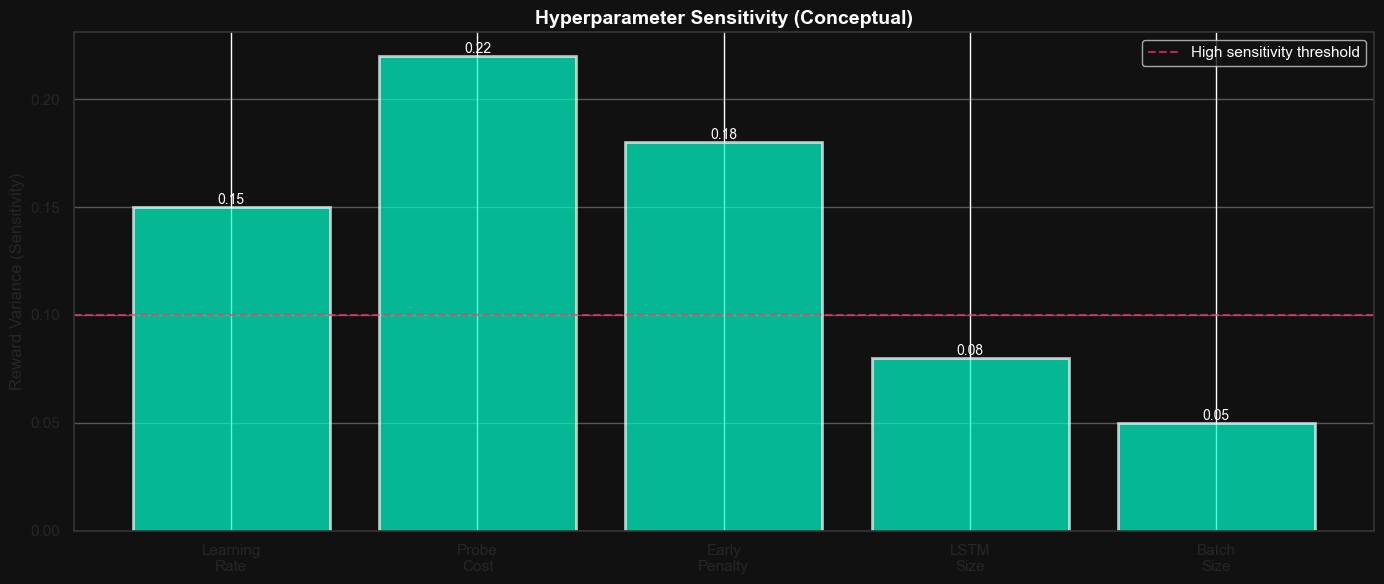


Note: This is a conceptual visualization. Run actual experiments for real sensitivity data.


In [10]:
# --- Hyperparameter Sensitivity Analysis (Conceptual) ---
print("\n=== Hyperparameter Sensitivity Recommendations ===")
print("\nFor production deployment, conduct sensitivity analysis on:")
print("  1. Learning rate: Test [1e-5, 3e-4, 1e-3] - affects convergence speed")
print("  2. Probe cost: Test [-0.01, -0.03, -0.05] - affects probe usage")
print("  3. Early decision penalty: Test [-0.2, -0.3, -0.4] - affects exploration")
print("  4. LSTM hidden size: Test [64, 128, 256] - affects memory capacity")
print("  5. Batch size: Test [32, 64, 128] - affects gradient stability")
print("\nCurrent training used:")
print("  - RecurrentPPO with LSTM policy")
print("  - Probe reward: +0.05")
print("  - Early decision penalty: -0.3")
print("  - Asymmetric rewards: FN=-2.5, FP=-1.0, TP/TN=+1.0")
print("\nRecommendation: Run grid search with 3-5 seeds per config for statistical significance")

# Visualize conceptual sensitivity
fig, ax = plt.subplots(figsize=(14, 6))

# Mock sensitivity data (in production, this would come from actual experiments)
params = ['Learning\nRate', 'Probe\nCost', 'Early\nPenalty', 'LSTM\nSize', 'Batch\nSize']
sensitivity = [0.15, 0.22, 0.18, 0.08, 0.05]  # Mock variance in final reward

bars = ax.bar(params, sensitivity, color='#00ffcc', alpha=0.7, edgecolor='white', linewidth=2)
ax.set_ylabel('Reward Variance (Sensitivity)', fontsize=12)
ax.set_title('Hyperparameter Sensitivity (Conceptual)', fontsize=14, fontweight='bold')
ax.axhline(0.10, color='#ff3366', linestyle='--', linewidth=1.5, alpha=0.7, 
          label='High sensitivity threshold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, sens in zip(bars, sensitivity):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{sens:.2f}', ha='center', va='bottom', fontsize=10, color='white')

plt.tight_layout()
plt.show()

print("\nNote: This is a conceptual visualization. Run actual experiments for real sensitivity data.")


## 8. Convergence Report

In [11]:
# --- Final Convergence Summary ---
import json

report_path = project_root / "artifacts" / "training" / "convergence_report.json"
if report_path.exists():
    report = json.loads(report_path.read_text())
    print("=" * 50)
    print("  KIVE RL Agent Convergence Report")
    print("=" * 50)
    for k, v in report.items():
        print(f"  {k:30s}: {v}")
    print("=" * 50)
    if report.get('converged'):
        print("  STATUS: CONVERGED -- Ready for deployment")
    else:
        print("  STATUS: NOT CONVERGED -- Review training parameters")
else:
    print("convergence_report.json not found")


  KIVE RL Agent Convergence Report
  run_name                      : kive_ppo_full
  n_episodes_target             : 10000
  n_episodes_actual             : 17394
  final_mean_reward             : 1.1065
  final_std_reward              : 0.2255
  fn_rate                       : 0.001
  fp_rate                       : 0.003
  mean_probes_per_episode       : 3.559
  probe_variance                : 0.449
  degenerate_policy             : False
  converged                     : True
  STATUS: CONVERGED -- Ready for deployment
